## Zadanie domowe: morfologiczna gra w życie – John Conway

### Wykorzystanie operacji LUT w przekształceniu trafi, nie trafi
  - Szybszą metodą wykonania transformacji trafi, nie trafi może być operacja LUT.
  - Technika polega na zakodowaniu wyników wszystkich interesujących  konfiguracji, a następnie podczas przetwarzania wykorzystania operacji LUT.
  - Dla otoczenia 3x3 możliwe jest 512 różnych konfiguracji.
  - Aby praktycznie zrealizować operacje, każdej konfiguracji należy nadać unikalny indeks. Jedną z możliwości jest pomnożenie elementu strukturalnego przez macierz (mnożenie odpowiednich elementów):
  ```
  [[1, 8,  64],
   [ 2, 16, 128],
   [ 4, 32, 256]]
  ```
  Przykładowo elementowi:
  ```
  [[1, 1, 0],
   [ 1, 0, 1],
   [ 1, 0, 1]]
  ```
  odpowiada liczba: 1(1) + 2(1) + 4(1) + 8(1) + 128(1) + 256(1) = 399.
  
### Przykład działania metody – detekcja punktów końcowych na obrazie.
  - założenie: punkt końcowy to punkt, który ma dokładnie jednego sąsiada,
  - zdefiniuj funkcję, która jako argument pobiera otoczenie, a zwraca 0 lub 1 w zależności od tego, czy rozpatrywany punkt jest końcowy np. dla sąsiedztwa 3×3 punkt będzie końcowy, jeżeli jest zapalony i ma tylko jednego sąsiada (czyli suma pikseli jest równa 2).
  - wygeneruj przekodowanie LUT.
  - wczytaj obraz szkielet.bmp (należy go przekształcić, aby uzyskać dwuwymiarową tablicę o wartościach 0-1). Wykorzystując wygenerowane przekodowanie LUT wykonaj detekcję zakończeń. Wyświetl obraz oryginalny i po przekodowaniu LUT.

### Gra w życie

Reguły gry w życie:
  - każdy piksel biały, który ma dwóch lub trzech sąsiadów (białych) przeżywa,
  - każdy piksel biały, który ma 0,1 lub więcej niż trzech sąsiadów (białych) nie przeżywa (głód lub przeludnienie),
  - jeżeli jakieś pole (czarne) sąsiaduje dokładnie z trzema pikselami białymi, to na tym polu ,,rodzi'' się nowy piksel biały.

Zadanie:
  - za pomocą mechanizmu LUT (opisanego wcześniej) należy zaimplementować morfologiczną gre w życie,
  - najważniejszym elementem jest funkcja opisująca reguły gry,
  - symulacje należny przeprowadzić dla plansz dostarczonych w pliku gra.py,
  - dobrze jest wykonać kilka iteracji – zobaczyć jak zmienia się kształt,
  - inne ciekawe kształty do znalezienia w internecie.


In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os


In [8]:
count=[[1,8,64],
       [2,16,128],
        [4,32,256]]

In [50]:
def get_ind(m):
    ind=0
    for i in range(3):
        for j in range(3):
            if m[i][j]!=0:
              ind+=count[i][j]
    return ind

In [55]:
lut=np.zeros(512)
for i in range(3):
    for j in range(3):
        lut[count[i][j]+16]=1
lut[32]=0

<Figure size 432x288 with 0 Axes>

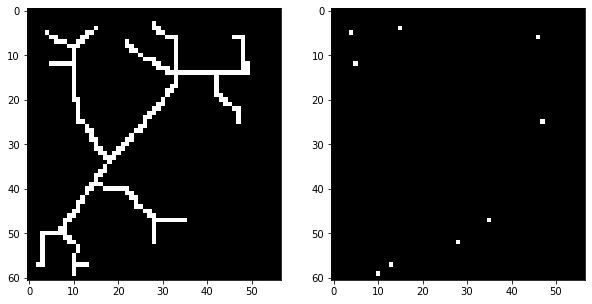

In [56]:
s=cv2.imread('szkielet.bmp',cv2.IMREAD_GRAYSCALE)
plt.gray()
x,y=s.shape
new=np.zeros((x,y))
for i in range(1,x-1):
    for j in range(1,y-1):
        v=get_ind(s[i-1:i+2,j-1:j+2])
        new[i][j]=lut[v]
fig,ax=plt.subplots(1,2,figsize=(10,20))
ax[0].imshow(s)
ax[1].imshow(new)

In [166]:
flat_count=[1,2,4,8,32,64,128,256]

loot_2=np.zeros(512)
loot_3=np.zeros(512)

for i in range(8):
    for j in range(i+1,8):
        ind=flat_count[i]+flat_count[j]
        loot_2[ind+16]=1
        for k in range(j+1,8):
            kind=ind+flat_count[k]
            loot_3[kind+16]=1

In [247]:
def game(img,iter,window_size=4):
    table=img.copy()
    fig,ax=plt.subplots(int(np.ceil(iter/window_size)),window_size,figsize=(window_size*2.5,int(np.ceil(iter/window_size))*window_size/2))
    ax[0][0].imshow(table)
    ax[0][0].axis('off')
    for it in range(iter):
        x,y=table.shape
        new=np.zeros((x,y))
        spr=np.zeros((x,y))
        for i in range(1,x-1):
            for j in range(1,y-1):
                if(table[i][j]==0):
                    v=get_ind(table[i-1:i+2,j-1:j+2])+16
                    new[i][j]=loot_3[v]
                else: 
                    v=get_ind(table[i-1:i+2,j-1:j+2])
                    new[i][j]=loot_2[v]+loot_3[v]
        ax[int(np.floor(it/window_size))][it%window_size].imshow(new)
        ax[int(np.floor(it/window_size))][it%window_size].axis('off')
        table=new


In [211]:
fontanna=plansza1 = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,1,0,1,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,1,1,0,1,0,1,0,1,1,0,0,0],
    [0,0,0,1,1,1,0,0,0,1,1,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]], np.uint8)


Obrazki oglądać od lewa do prawa

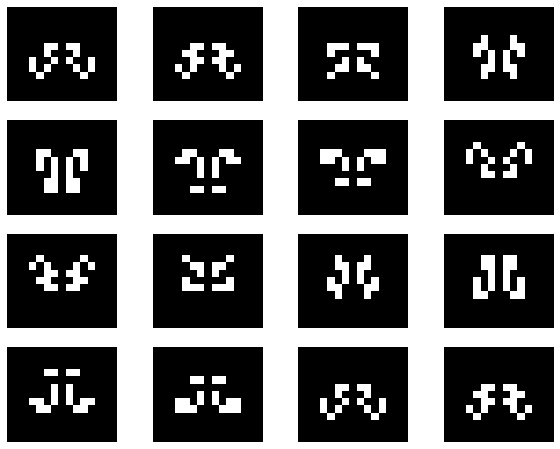

In [248]:
po=game(fontanna,16)


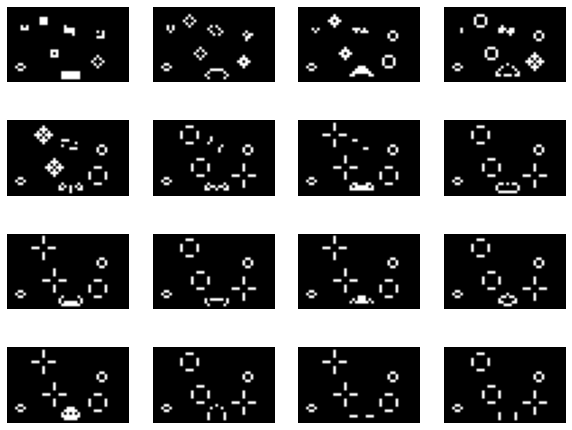

In [252]:
h=cv2.imread('hom.bmp',cv2.IMREAD_GRAYSCALE)
game(h,16)
